# Code Example: Center-of-Mass (COM) Calculation for DPC

## Overview

This example demonstrates the **Center-of-Mass (COM)** calculation, which is the fundamental measurement in **Differential Phase Contrast (DPC)** imaging. Understanding COM is essential for quantitative phase imaging and field mapping.

## Theoretical Background

### Center-of-Mass Definition

The **Center-of-Mass** quantifies the centroid of the diffraction intensity distribution:

$$
\vec{\text{COM}}(\vec{r}) = \frac{\iint \vec{\theta} \cdot I(\vec{r}, \vec{\theta}) \, d^2\theta}{\iint I(\vec{r}, \vec{\theta}) \, d^2\theta}
$$

where:
- **r**: Real-space probe position (x, y)
- **θ**: Detector position (scattering angle)
- **I(r, θ)**: Diffraction intensity at position r with scattering angle θ
- **COM(r)**: Vector pointing to intensity centroid

### Component Form

In practice, we calculate **x** and **y** components separately:

$$
\text{COM}_x(\vec{r}) = \frac{\iint \theta_x \cdot I(\vec{r}, \vec{\theta}) \, d^2\theta}{\iint I(\vec{r}, \vec{\theta}) \, d^2\theta}
$$

$$
\text{COM}_y(\vec{r}) = \frac{\iint \theta_y \cdot I(\vec{r}, \vec{\theta}) \, d^2\theta}{\iint I(\vec{r}, \vec{\theta}) \, d^2\theta}
$$

### Physical Interpretation

**COM measures beam deflection**:
- Undeflected beam → COM at detector center (0, 0)
- Beam deflected by phase gradient → COM shifts
- **COM shift ∝ Phase gradient**

### Relationship to DPC

The **DPC signal** is the COM shift relative to a reference:

$$
\text{DPC}(\vec{r}) = \vec{\text{COM}}(\vec{r}) - \vec{\text{COM}}_{\text{ref}}
$$

For small deflections:

$$
\text{DPC}(\vec{r}) \approx \frac{\lambda}{2\pi} \nabla \phi(\vec{r})
$$

where φ is the phase and λ is the wavelength.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Circle

print("Center-of-Mass (COM) Calculation for DPC")
print("=" * 60)

Center-of-Mass (COM) Calculation for DPC


## Part 1: Discrete COM Calculation

For digital detectors, the integral becomes a **discrete sum**:

$$
\text{COM}_x = \frac{\sum_{i,j} i \cdot I_{i,j}}{\sum_{i,j} I_{i,j}}, \quad \text{COM}_y = \frac{\sum_{i,j} j \cdot I_{i,j}}{\sum_{i,j} I_{i,j}}
$$

where:
- **i, j**: Pixel indices on detector
- **I_{i,j}**: Intensity at pixel (i, j)

This is a **weighted average** of pixel positions.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Example 1: Centered Beam
  Expected COM: (64, 64)
  Calculated COM: (64.00, 64.00)
  Difference: (-1.90e-04, -1.90e-04)

Example 2: Deflected Beam
  Applied shift: (10, -5)
  Calculated COM: (73.99, 59.00)
  Measured shift: (9.99, -5.00)
  Recovery accuracy: 1.01e-02, 2.30e-03


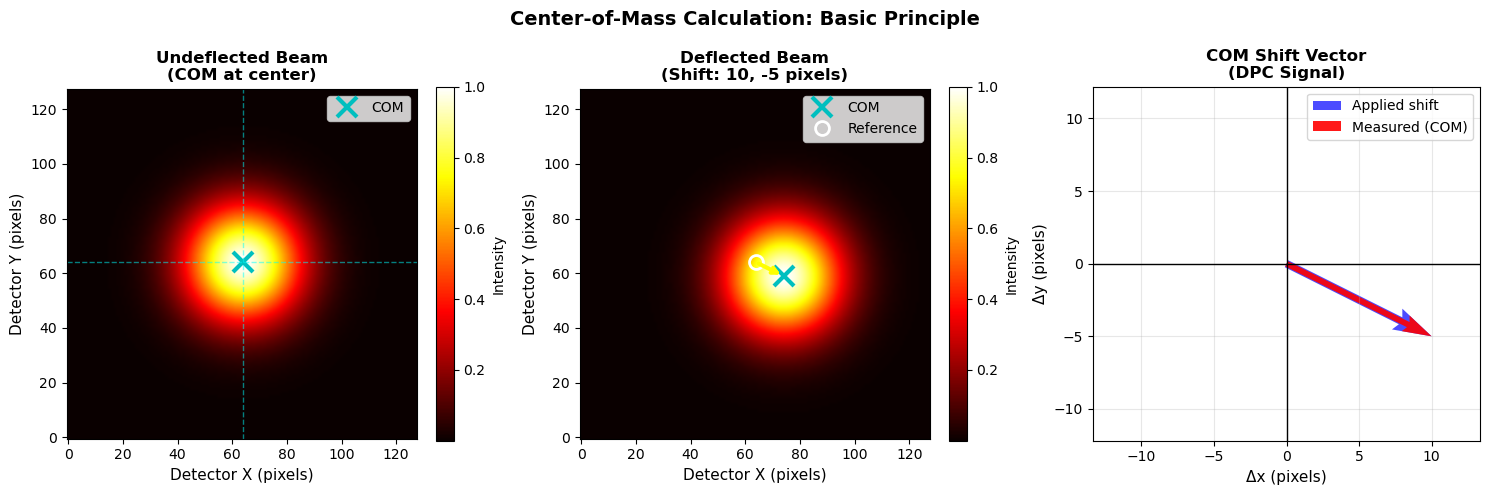


✓ COM successfully measures beam deflection!


In [2]:
def calculate_com(diffraction_pattern):
    """
    Calculate the center-of-mass of a diffraction pattern.
    
    Parameters:
    -----------
    diffraction_pattern : 2D array
        Diffraction intensity I(θ_x, θ_y)
    
    Returns:
    --------
    com_x, com_y : float
        Center-of-mass coordinates (in pixels)
    """
    # Get the shape
    Ny, Nx = diffraction_pattern.shape
    
    # Create coordinate arrays (pixel indices)
    y_coords, x_coords = np.meshgrid(np.arange(Ny), np.arange(Nx), indexing='ij')
    
    # Total intensity
    total_intensity = np.sum(diffraction_pattern)
    
    # Weighted average
    if total_intensity > 0:
        com_x = np.sum(x_coords * diffraction_pattern) / total_intensity
        com_y = np.sum(y_coords * diffraction_pattern) / total_intensity
    else:
        # No signal - return center
        com_x = Nx / 2
        com_y = Ny / 2
    
    return com_x, com_y


# Demonstrate with a simple example

# Create a detector grid
detector_size = 128
y_det, x_det = np.meshgrid(np.arange(detector_size), np.arange(detector_size), indexing='ij')

# Example 1: Centered Gaussian (undeflected beam)
center_x, center_y = detector_size // 2, detector_size // 2
sigma = 15  # Beam width

intensity_centered = np.exp(-((x_det - center_x)**2 + (y_det - center_y)**2) / (2 * sigma**2))

com_x_centered, com_y_centered = calculate_com(intensity_centered)

print(f"Example 1: Centered Beam")
print(f"  Expected COM: ({center_x}, {center_y})")
print(f"  Calculated COM: ({com_x_centered:.2f}, {com_y_centered:.2f})")
print(f"  Difference: ({com_x_centered - center_x:.2e}, {com_y_centered - center_y:.2e})")

# Example 2: Shifted Gaussian (deflected beam)
shift_x, shift_y = 10, -5  # Beam deflection in pixels
intensity_shifted = np.exp(-((x_det - center_x - shift_x)**2 + 
                             (y_det - center_y - shift_y)**2) / (2 * sigma**2))

com_x_shifted, com_y_shifted = calculate_com(intensity_shifted)
measured_shift_x = com_x_shifted - com_x_centered
measured_shift_y = com_y_shifted - com_y_centered

print(f"\nExample 2: Deflected Beam")
print(f"  Applied shift: ({shift_x}, {shift_y})")
print(f"  Calculated COM: ({com_x_shifted:.2f}, {com_y_shifted:.2f})")
print(f"  Measured shift: ({measured_shift_x:.2f}, {measured_shift_y:.2f})")
print(f"  Recovery accuracy: {np.abs(measured_shift_x - shift_x):.2e}, {np.abs(measured_shift_y - shift_y):.2e}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Centered beam
ax = axes[0]
im = ax.imshow(intensity_centered, cmap='hot', origin='lower', interpolation='bilinear')
ax.plot(com_x_centered, com_y_centered, 'cx', markersize=15, markeredgewidth=3, label='COM')
ax.axhline(center_y, color='cyan', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(center_x, color='cyan', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Detector X (pixels)', fontsize=11)
ax.set_ylabel('Detector Y (pixels)', fontsize=11)
ax.set_title('Undeflected Beam\n(COM at center)', fontsize=12, weight='bold')
ax.legend(fontsize=10, loc='upper right')
plt.colorbar(im, ax=ax, fraction=0.046, label='Intensity')

# Shifted beam
ax = axes[1]
im = ax.imshow(intensity_shifted, cmap='hot', origin='lower', interpolation='bilinear')
ax.plot(com_x_shifted, com_y_shifted, 'cx', markersize=15, markeredgewidth=3, label='COM')
ax.plot(com_x_centered, com_y_centered, 'wo', markersize=10, markeredgewidth=2, 
       label='Reference', fillstyle='none')
# Draw arrow showing COM shift
ax.annotate('', xy=(com_x_shifted, com_y_shifted), 
           xytext=(com_x_centered, com_y_centered),
           arrowprops=dict(arrowstyle='->', color='yellow', lw=3))
ax.set_xlabel('Detector X (pixels)', fontsize=11)
ax.set_ylabel('Detector Y (pixels)', fontsize=11)
ax.set_title(f'Deflected Beam\n(Shift: {shift_x}, {shift_y} pixels)', fontsize=12, weight='bold')
ax.legend(fontsize=10, loc='upper right')
plt.colorbar(im, ax=ax, fraction=0.046, label='Intensity')

# COM shift vector
ax = axes[2]
ax.quiver(0, 0, shift_x, shift_y, angles='xy', scale_units='xy', scale=1, 
         color='blue', width=0.02, label='Applied shift', alpha=0.7)
ax.quiver(0, 0, measured_shift_x, measured_shift_y, angles='xy', scale_units='xy', scale=1,
         color='red', width=0.015, label='Measured (COM)', alpha=0.9)
ax.set_xlabel('Δx (pixels)', fontsize=11)
ax.set_ylabel('Δy (pixels)', fontsize=11)
ax.set_title('COM Shift Vector\n(DPC Signal)', fontsize=12, weight='bold')
ax.grid(alpha=0.3)
ax.axhline(0, color='k', linewidth=1)
ax.axvline(0, color='k', linewidth=1)
ax.legend(fontsize=10)
ax.axis('equal')
ax.set_xlim(-15, 15)
ax.set_ylim(-15, 15)

plt.suptitle('Center-of-Mass Calculation: Basic Principle', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n✓ COM successfully measures beam deflection!")

## Part 2: COM from 4D-STEM Data

In **4D-STEM**, we record a full diffraction pattern at each probe position:
- **4D dataset**: I(r_x, r_y, θ_x, θ_y)
- **Dimensions**: (scan_x, scan_y, detector_x, detector_y)

For each probe position **(r_x, r_y)**, we calculate **COM(r_x, r_y)**:

$$
\text{COM}_x(r_x, r_y) = \frac{\sum_{i,j} i \cdot I(r_x, r_y, i, j)}{\sum_{i,j} I(r_x, r_y, i, j)}
$$

Result: **2D COM maps** showing beam deflection across the sample.


Simulated 4D-STEM Dataset:
  Scan size: 32 × 32
  Detector size: 64 × 64
  Phase gradient: (∇φ_x, ∇φ_y) = (0.5, 0.3) rad/nm
  Expected beam deflection: (5.00, 3.00) pixels

Calculating COM maps...

COM Analysis:
  Average COM: (36.77, 34.86) pixels
  Expected: (37.00, 35.00) pixels
  DPC range: x [-0.054, 0.085], y [-0.054, 0.064] pixels


/var/folders/m3/fdsx0z8944b6_th83kt65w_r0000gn/T/ipykernel_86892/2072971456.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


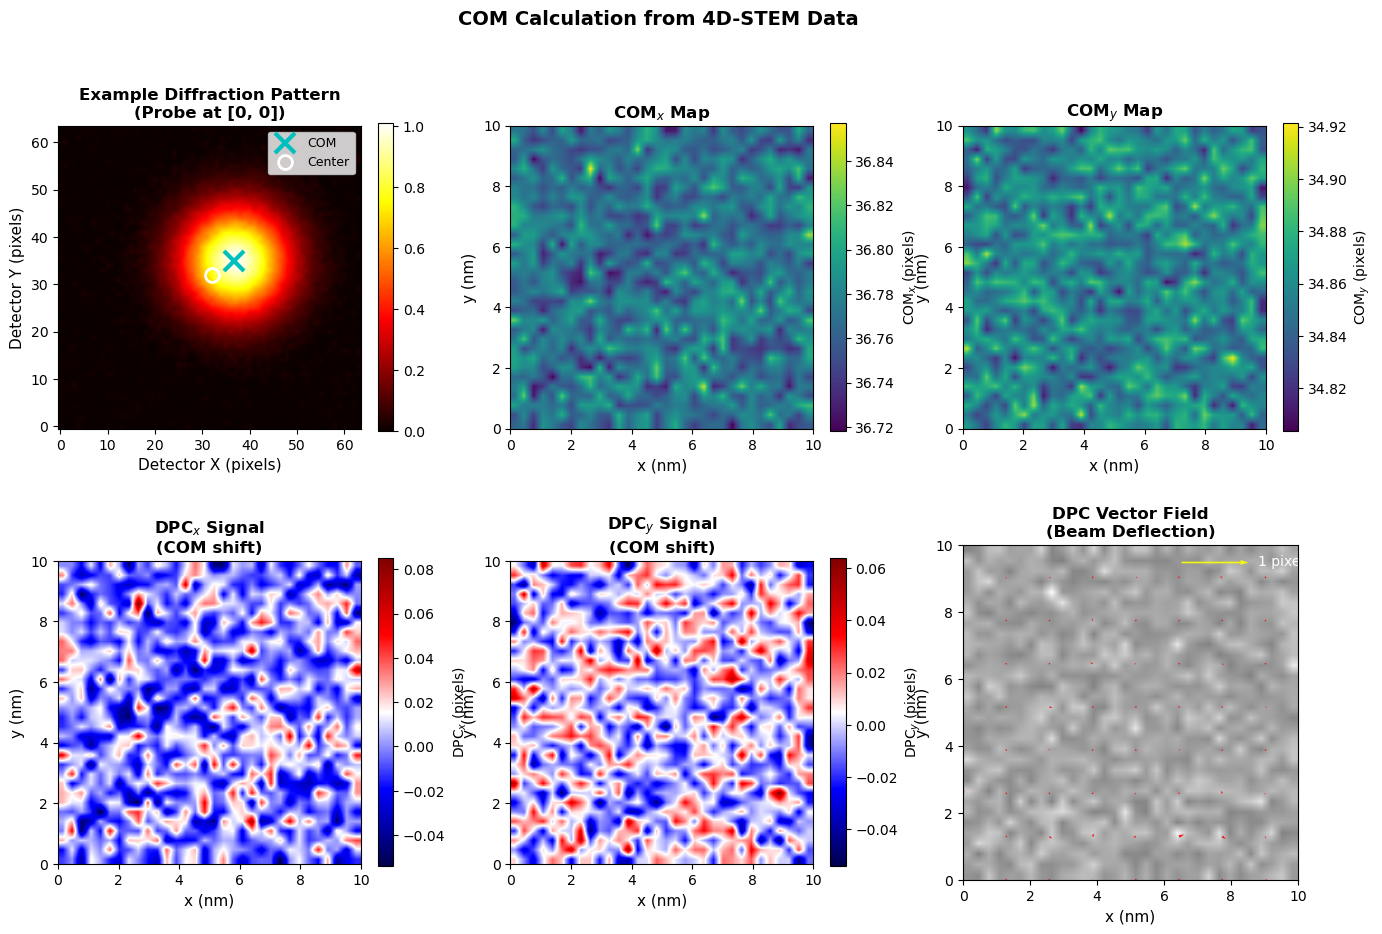


✓ COM maps successfully extracted from 4D-STEM data!


In [3]:
def calculate_com_4dstem(data_4d):
    """
    Calculate COM for a 4D-STEM dataset.
    
    Parameters:
    -----------
    data_4d : 4D array, shape (scan_y, scan_x, det_y, det_x)
        4D-STEM dataset
    
    Returns:
    --------
    com_x, com_y : 2D arrays, shape (scan_y, scan_x)
        Center-of-mass maps
    """
    scan_y, scan_x, det_y, det_x = data_4d.shape
    
    # Initialize COM arrays
    com_x_map = np.zeros((scan_y, scan_x))
    com_y_map = np.zeros((scan_y, scan_x))
    
    # Detector coordinate grids
    det_yy, det_xx = np.meshgrid(np.arange(det_y), np.arange(det_x), indexing='ij')
    
    # Calculate COM for each probe position
    for iy in range(scan_y):
        for ix in range(scan_x):
            # Get diffraction pattern at this position
            dp = data_4d[iy, ix, :, :]
            
            # Total intensity
            total_int = np.sum(dp)
            
            if total_int > 0:
                # Weighted average
                com_x_map[iy, ix] = np.sum(det_xx * dp) / total_int
                com_y_map[iy, ix] = np.sum(det_yy * dp) / total_int
            else:
                # No signal - use detector center
                com_x_map[iy, ix] = det_x / 2
                com_y_map[iy, ix] = det_y / 2
    
    return com_x_map, com_y_map


# Simulate a simple 4D-STEM dataset

# Scan parameters
scan_size = 32  # Small for demonstration
detector_size_sim = 64

# Create phase gradient (linear ramp - constant phase gradient)
x_scan = np.linspace(0, 10, scan_size)  # nm
y_scan = np.linspace(0, 10, scan_size)
X_scan, Y_scan = np.meshgrid(x_scan, y_scan)

# Phase with gradient (simulating electric field)
# φ(x, y) = a*x + b*y  => ∇φ = (a, b)
gradient_x = 0.5  # rad/nm
gradient_y = 0.3  # rad/nm
phase = gradient_x * X_scan + gradient_y * Y_scan

# Beam deflection proportional to phase gradient
# For simplicity: deflection (pixels) = k * gradient
k_deflection = 10  # Calibration constant
deflection_x = gradient_x * k_deflection
deflection_y = gradient_y * k_deflection

print(f"\nSimulated 4D-STEM Dataset:")
print(f"  Scan size: {scan_size} × {scan_size}")
print(f"  Detector size: {detector_size_sim} × {detector_size_sim}")
print(f"  Phase gradient: (∇φ_x, ∇φ_y) = ({gradient_x}, {gradient_y}) rad/nm")
print(f"  Expected beam deflection: ({deflection_x:.2f}, {deflection_y:.2f}) pixels")

# Create 4D dataset
data_4d_sim = np.zeros((scan_size, scan_size, detector_size_sim, detector_size_sim))

center_det_x = detector_size_sim // 2
center_det_y = detector_size_sim // 2
sigma_beam = 8  # Beam size on detector

det_yy, det_xx = np.meshgrid(np.arange(detector_size_sim), 
                             np.arange(detector_size_sim), indexing='ij')

# Fill 4D dataset with deflected beams
for iy in range(scan_size):
    for ix in range(scan_size):
        # Beam position shifts due to phase gradient
        # (In reality, this would vary with local fields)
        beam_x = center_det_x + deflection_x
        beam_y = center_det_y + deflection_y
        
        # Gaussian beam
        data_4d_sim[iy, ix, :, :] = np.exp(-((det_xx - beam_x)**2 + 
                                             (det_yy - beam_y)**2) / (2 * sigma_beam**2))
        
        # Add noise
        data_4d_sim[iy, ix, :, :] += np.random.normal(0, 0.01, (detector_size_sim, detector_size_sim))
        data_4d_sim[iy, ix, :, :] = np.maximum(data_4d_sim[iy, ix, :, :], 0)

print(f"\nCalculating COM maps...")
com_x_map, com_y_map = calculate_com_4dstem(data_4d_sim)

# Reference COM (vacuum or average)
com_x_ref = np.mean(com_x_map)
com_y_ref = np.mean(com_y_map)

# DPC signal = COM shift from reference
dpc_x = com_x_map - com_x_ref
dpc_y = com_y_map - com_y_ref

print(f"\nCOM Analysis:")
print(f"  Average COM: ({com_x_ref:.2f}, {com_y_ref:.2f}) pixels")
print(f"  Expected: ({center_det_x + deflection_x:.2f}, {center_det_y + deflection_y:.2f}) pixels")
print(f"  DPC range: x [{dpc_x.min():.3f}, {dpc_x.max():.3f}], y [{dpc_y.min():.3f}, {dpc_y.max():.3f}] pixels")

# Visualize
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.35)

# Example diffraction patterns
ax1 = fig.add_subplot(gs[0, 0])
# Show DP from corner
dp_example = data_4d_sim[0, 0, :, :]
im1 = ax1.imshow(dp_example, cmap='hot', origin='lower', interpolation='bilinear')
com_ex_x, com_ex_y = calculate_com(dp_example)
ax1.plot(com_ex_x, com_ex_y, 'cx', markersize=15, markeredgewidth=3, label='COM')
ax1.plot(center_det_x, center_det_y, 'wo', markersize=10, markeredgewidth=2, 
        label='Center', fillstyle='none')
ax1.set_xlabel('Detector X (pixels)', fontsize=11)
ax1.set_ylabel('Detector Y (pixels)', fontsize=11)
ax1.set_title(f'Example Diffraction Pattern\n(Probe at [0, 0])', fontsize=12, weight='bold')
ax1.legend(fontsize=9, loc='upper right')
plt.colorbar(im1, ax=ax1, fraction=0.046)

# COM_x map
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(com_x_map, extent=[0, 10, 0, 10], cmap='viridis', 
                origin='lower', interpolation='bilinear')
ax2.set_xlabel('x (nm)', fontsize=11)
ax2.set_ylabel('y (nm)', fontsize=11)
ax2.set_title('COM$_x$ Map', fontsize=12, weight='bold')
cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046)
cbar2.set_label('COM$_x$ (pixels)', fontsize=10)

# COM_y map
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(com_y_map, extent=[0, 10, 0, 10], cmap='viridis',
                origin='lower', interpolation='bilinear')
ax3.set_xlabel('x (nm)', fontsize=11)
ax3.set_ylabel('y (nm)', fontsize=11)
ax3.set_title('COM$_y$ Map', fontsize=12, weight='bold')
cbar3 = plt.colorbar(im3, ax=ax3, fraction=0.046)
cbar3.set_label('COM$_y$ (pixels)', fontsize=10)

# DPC_x (COM shift)
ax4 = fig.add_subplot(gs[1, 0])
im4 = ax4.imshow(dpc_x, extent=[0, 10, 0, 10], cmap='seismic',
                origin='lower', interpolation='bilinear')
ax4.set_xlabel('x (nm)', fontsize=11)
ax4.set_ylabel('y (nm)', fontsize=11)
ax4.set_title('DPC$_x$ Signal\n(COM shift)', fontsize=12, weight='bold')
cbar4 = plt.colorbar(im4, ax=ax4, fraction=0.046)
cbar4.set_label('DPC$_x$ (pixels)', fontsize=10)

# DPC_y
ax5 = fig.add_subplot(gs[1, 1])
im5 = ax5.imshow(dpc_y, extent=[0, 10, 0, 10], cmap='seismic',
                origin='lower', interpolation='bilinear')
ax5.set_xlabel('x (nm)', fontsize=11)
ax5.set_ylabel('y (nm)', fontsize=11)
ax5.set_title('DPC$_y$ Signal\n(COM shift)', fontsize=12, weight='bold')
cbar5 = plt.colorbar(im5, ax=ax5, fraction=0.046)
cbar5.set_label('DPC$_y$ (pixels)', fontsize=10)

# Vector field
ax6 = fig.add_subplot(gs[1, 2])
stride = 4
X_sub = X_scan[::stride, ::stride]
Y_sub = Y_scan[::stride, ::stride]
dpc_x_sub = dpc_x[::stride, ::stride]
dpc_y_sub = dpc_y[::stride, ::stride]

magnitude = np.sqrt(dpc_x**2 + dpc_y**2)
im6 = ax6.imshow(magnitude, extent=[0, 10, 0, 10], cmap='gray', 
                origin='lower', alpha=0.5, interpolation='bilinear')
quiver = ax6.quiver(X_sub, Y_sub, dpc_x_sub, dpc_y_sub, 
                   color='red', scale=5, width=0.005, alpha=0.9)
ax6.set_xlabel('x (nm)', fontsize=11)
ax6.set_ylabel('y (nm)', fontsize=11)
ax6.set_title('DPC Vector Field\n(Beam Deflection)', fontsize=12, weight='bold')
ax6.quiverkey(quiver, 0.85, 0.95, 1, '1 pixel', labelpos='E',
             coordinates='axes', color='yellow', labelcolor='white')

plt.suptitle('COM Calculation from 4D-STEM Data', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n✓ COM maps successfully extracted from 4D-STEM data!")

## Part 3: Physical Interpretation - Phase Gradients

### Relationship between COM and Phase

The **beam deflection** measured by COM is related to the **phase gradient**:

**Geometric optics approximation:**
$$
\Delta \theta \approx \frac{\lambda}{2\pi} \nabla \phi
$$

where:
- **Δθ**: Beam deflection angle
- **λ**: Electron wavelength
- **∇φ**: Phase gradient

### In detector coordinates:

$$
\text{COM}_x - \text{COM}_{\text{ref}} = C_x \cdot \frac{\partial \phi}{\partial x}
$$

$$
\text{COM}_y - \text{COM}_{\text{ref}} = C_y \cdot \frac{\partial \phi}{\partial y}
$$

where **C** is a calibration constant depending on:
- Camera length
- Pixel size
- Wavelength

/var/folders/m3/fdsx0z8944b6_th83kt65w_r0000gn/T/ipykernel_86892/3041044747.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


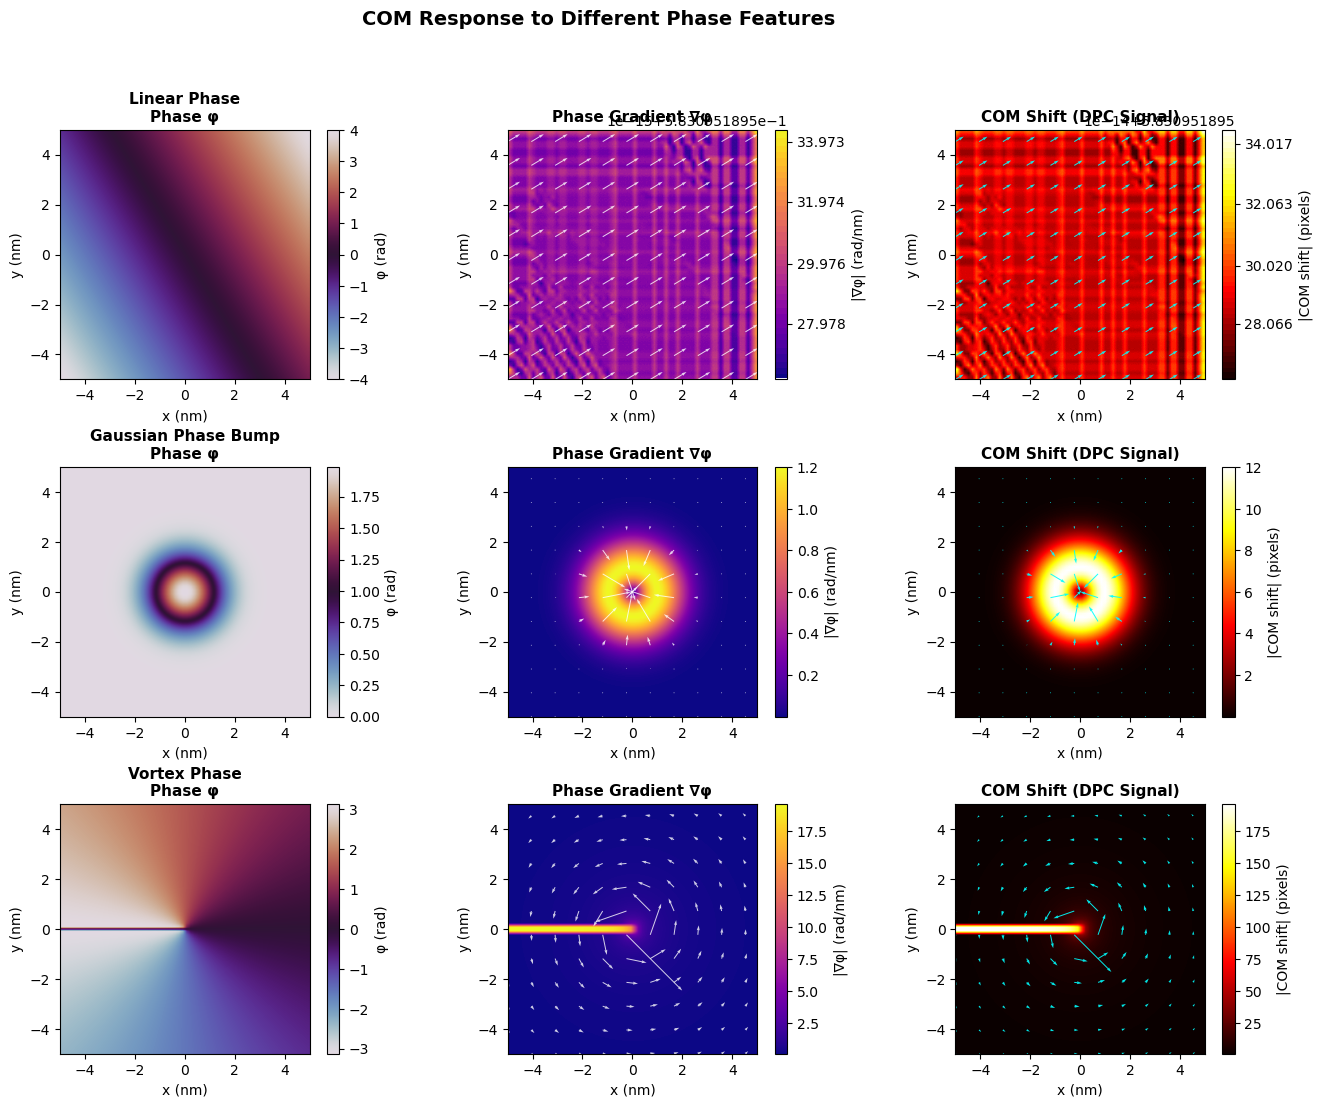


Physical Interpretation:
  • Linear phase → Uniform COM shift (constant deflection)
  • Gaussian bump → Radial COM pattern (diverging beam)
  • Vortex phase → Circular COM pattern (rotating beam)
  • COM directly visualizes phase gradients!


In [5]:
# Demonstrate COM response to different phase features

# Create test phase objects
scan_size_test = 64
x_test = np.linspace(-5, 5, scan_size_test)  # nm
y_test = np.linspace(-5, 5, scan_size_test)
X_test, Y_test = np.meshgrid(x_test, y_test)

# Test case 1: Linear phase (constant gradient)
phase_linear = 0.5 * X_test + 0.3 * Y_test
grad_x_linear = np.gradient(phase_linear, x_test[1] - x_test[0], axis=1)
grad_y_linear = np.gradient(phase_linear, y_test[1] - y_test[0], axis=0)

# Test case 2: Gaussian phase bump (radial gradient)
r_test = np.sqrt(X_test**2 + Y_test**2)
phase_gaussian = 2.0 * np.exp(-r_test**2 / 2)
grad_x_gaussian = np.gradient(phase_gaussian, x_test[1] - x_test[0], axis=1)
grad_y_gaussian = np.gradient(phase_gaussian, y_test[1] - y_test[0], axis=0)

# Test case 3: Vortex phase (circular gradient)
phase_vortex = np.arctan2(Y_test, X_test)
grad_x_vortex = np.gradient(phase_vortex, x_test[1] - x_test[0], axis=1)
grad_y_vortex = np.gradient(phase_vortex, y_test[1] - y_test[0], axis=0)

# Simulate COM response (simplified: COM shift ∝ gradient)
calibration = 10  # pixels per rad/nm

com_shift_x_linear = calibration * grad_x_linear
com_shift_y_linear = calibration * grad_y_linear

com_shift_x_gaussian = calibration * grad_x_gaussian
com_shift_y_gaussian = calibration * grad_y_gaussian

com_shift_x_vortex = calibration * grad_x_vortex
com_shift_y_vortex = calibration * grad_y_vortex

# Visualize
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

test_cases = [
    ("Linear Phase", phase_linear, grad_x_linear, grad_y_linear, 
     com_shift_x_linear, com_shift_y_linear),
    ("Gaussian Phase Bump", phase_gaussian, grad_x_gaussian, grad_y_gaussian,
     com_shift_x_gaussian, com_shift_y_gaussian),
    ("Vortex Phase", phase_vortex, grad_x_vortex, grad_y_vortex,
     com_shift_x_vortex, com_shift_y_vortex)
]

for row, (title, phase, gx, gy, cx, cy) in enumerate(test_cases):
    # Phase
    ax = fig.add_subplot(gs[row, 0])
    im = ax.imshow(phase, extent=[-5, 5, -5, 5], cmap='twilight',
                  origin='lower', interpolation='bilinear')
    ax.set_xlabel('x (nm)', fontsize=10)
    ax.set_ylabel('y (nm)', fontsize=10)
    ax.set_title(f'{title}\nPhase φ', fontsize=11, weight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, label='φ (rad)')
    
    # Phase gradient
    ax = fig.add_subplot(gs[row, 1])
    magnitude = np.sqrt(gx**2 + gy**2)
    im = ax.imshow(magnitude, extent=[-5, 5, -5, 5], cmap='plasma',
                  origin='lower', interpolation='bilinear')
    # Vector overlay
    stride = 6
    X_sub = X_test[::stride, ::stride]
    Y_sub = Y_test[::stride, ::stride]
    gx_sub = gx[::stride, ::stride]
    gy_sub = gy[::stride, ::stride]
    ax.quiver(X_sub, Y_sub, gx_sub, gy_sub, color='white', scale=10, width=0.004, alpha=0.8)
    ax.set_xlabel('x (nm)', fontsize=10)
    ax.set_ylabel('y (nm)', fontsize=10)
    ax.set_title('Phase Gradient ∇φ', fontsize=11, weight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, label='|∇φ| (rad/nm)')
    
    # COM shift (DPC signal)
    ax = fig.add_subplot(gs[row, 2])
    com_magnitude = np.sqrt(cx**2 + cy**2)
    im = ax.imshow(com_magnitude, extent=[-5, 5, -5, 5], cmap='hot',
                  origin='lower', interpolation='bilinear')
    # Vector overlay
    cx_sub = cx[::stride, ::stride]
    cy_sub = cy[::stride, ::stride]
    ax.quiver(X_sub, Y_sub, cx_sub, cy_sub, color='cyan', scale=150, width=0.004, alpha=0.9)
    ax.set_xlabel('x (nm)', fontsize=10)
    ax.set_ylabel('y (nm)', fontsize=10)
    ax.set_title('COM Shift (DPC Signal)', fontsize=11, weight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, label='|COM shift| (pixels)')

plt.suptitle('COM Response to Different Phase Features', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\nPhysical Interpretation:")
print("  • Linear phase → Uniform COM shift (constant deflection)")
print("  • Gaussian bump → Radial COM pattern (diverging beam)")
print("  • Vortex phase → Circular COM pattern (rotating beam)")
print("  • COM directly visualizes phase gradients!")

## Part 4: Practical Considerations

### Background Subtraction

Real data has **background** from:
- Detector dark current
- Stray scattering
- Amorphous layers

**Solution**: Subtract background or use vacuum reference

### Normalization

Total intensity may vary:
- Probe current fluctuations
- Sample thickness variations
- Scan drift

**Solution**: Normalize by total intensity (already done in COM formula)

### Bright Field Disk Selection

For **convergent beam**:
- Only use bright field disk
- Apply **circular mask** to exclude diffracted beams
- Reduces artifacts from Bragg scattering

### Calibration

Convert **pixel shifts** to **physical units**:

$$
\alpha_{\text{deflection}} = \Delta_{\text{COM}} \times \frac{\text{pixel size}}{\text{camera length}}
$$

Then relate to phase gradient using wavelength.

In [ ]:
# Demonstrate practical COM calculation with masking and background

# Simulate realistic diffraction pattern with complications

def create_realistic_dp(beam_shift_x, beam_shift_y, add_background=True, add_bragg=True):
    """
    Create a realistic diffraction pattern with background and Bragg peaks.
    """
    detector_size = 128
    det_y, det_x = np.meshgrid(np.arange(detector_size), np.arange(detector_size), indexing='ij')
    center = detector_size // 2
    
    # Bright field disk (deflected)
    sigma_bf = 12
    bf_x = center + beam_shift_x
    bf_y = center + beam_shift_y
    bf_disk = np.exp(-((det_x - bf_x)**2 + (det_y - bf_y)**2) / (2 * sigma_bf**2))
    
    # Total intensity
    intensity = bf_disk.copy()
    
    # Add Bragg peaks (diffracted beams)
    if add_bragg:
        # Simulate a few Bragg peaks
        bragg_positions = [(center + 30, center), (center - 30, center),
                          (center, center + 30), (center, center - 30)]
        sigma_bragg = 5
        for bx, by in bragg_positions:
            bragg = 0.3 * np.exp(-((det_x - bx)**2 + (det_y - by)**2) / (2 * sigma_bragg**2))
            intensity += bragg
    
    # Add background
    if add_background:
        background = 0.05 * np.ones_like(intensity)
        intensity += background
    
    # Add noise
    intensity += np.random.poisson(50 * intensity) / 50
    intensity = np.maximum(intensity, 0)
    
    return intensity


# Test different processing approaches

beam_shift_test = (8, -5)  # True beam deflection

# Case 1: Raw (with background and Bragg)
dp_raw = create_realistic_dp(beam_shift_test[0], beam_shift_test[1], 
                             add_background=True, add_bragg=True)
com_raw = calculate_com(dp_raw)

# Case 2: Background subtracted
dp_background = create_realistic_dp(0, 0, add_background=True, add_bragg=False)
dp_corrected = dp_raw - dp_background
dp_corrected = np.maximum(dp_corrected, 0)  # No negative values
com_corrected = calculate_com(dp_corrected)

# Case 3: Masked (bright field only)
mask_bf = np.zeros_like(dp_raw)
center = dp_raw.shape[0] // 2
radius_mask = 25  # BF disk radius
y_mask, x_mask = np.ogrid[:dp_raw.shape[0], :dp_raw.shape[1]]
mask_bf[(x_mask - center)**2 + (y_mask - center)**2 <= radius_mask**2] = 1.0

dp_masked = dp_raw * mask_bf
com_masked = calculate_com(dp_masked)

# Reference (ideal)
dp_ideal = create_realistic_dp(beam_shift_test[0], beam_shift_test[1],
                               add_background=False, add_bragg=False)
com_ideal = calculate_com(dp_ideal)

print(f"COM Calculation: Processing Effects")
print(f"  True beam shift: {beam_shift_test}")
print(f"\nCOM Results (relative to detector center {center}):")
print(f"  Ideal (no artifacts):    ({com_ideal[0] - center:.2f}, {com_ideal[1] - center:.2f})")
print(f"  Raw (with background):   ({com_raw[0] - center:.2f}, {com_raw[1] - center:.2f})")
print(f"  Background subtracted:   ({com_corrected[0] - center:.2f}, {com_corrected[1] - center:.2f})")
print(f"  BF masked:               ({com_masked[0] - center:.2f}, {com_masked[1] - center:.2f})")

print(f"\nErrors (compared to ideal):")
print(f"  Raw:        Δx = {com_raw[0] - com_ideal[0]:.3f}, Δy = {com_raw[1] - com_ideal[1]:.3f}")
print(f"  Corrected:  Δx = {com_corrected[0] - com_ideal[0]:.3f}, Δy = {com_corrected[1] - com_ideal[1]:.3f}")
print(f"  Masked:     Δx = {com_masked[0] - com_ideal[0]:.3f}, Δy = {com_masked[1] - com_ideal[1]:.3f}")

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Ideal
ax = axes[0, 0]
im = ax.imshow(dp_ideal, cmap='hot', origin='lower', interpolation='bilinear')
ax.plot(com_ideal[0], com_ideal[1], 'cx', markersize=15, markeredgewidth=3)
ax.plot(center, center, 'wo', markersize=10, markeredgewidth=2, fillstyle='none')
ax.set_title('Ideal (No Artifacts)', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xlabel('Detector X', fontsize=10)
ax.set_ylabel('Detector Y', fontsize=10)

# Raw
ax = axes[0, 1]
im = ax.imshow(dp_raw, cmap='hot', origin='lower', interpolation='bilinear')
ax.plot(com_raw[0], com_raw[1], 'cx', markersize=15, markeredgewidth=3, label='COM')
ax.plot(center, center, 'wo', markersize=10, markeredgewidth=2, fillstyle='none', label='Center')
ax.set_title('Raw (Background + Bragg)', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xlabel('Detector X', fontsize=10)
ax.legend(fontsize=9, loc='upper right')

# Background
ax = axes[0, 2]
im = ax.imshow(dp_background, cmap='hot', origin='lower', interpolation='bilinear')
ax.set_title('Background Reference', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xlabel('Detector X', fontsize=10)

# Corrected
ax = axes[1, 0]
im = ax.imshow(dp_corrected, cmap='hot', origin='lower', interpolation='bilinear')
ax.plot(com_corrected[0], com_corrected[1], 'cx', markersize=15, markeredgewidth=3)
ax.plot(center, center, 'wo', markersize=10, markeredgewidth=2, fillstyle='none')
ax.set_title('Background Subtracted', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xlabel('Detector X', fontsize=10)
ax.set_ylabel('Detector Y', fontsize=10)

# Mask
ax = axes[1, 1]
im = ax.imshow(mask_bf, cmap='gray', origin='lower', interpolation='nearest')
circle = Circle((center, center), radius_mask, fill=False, edgecolor='cyan', linewidth=2)
ax.add_patch(circle)
ax.set_title(f'BF Mask (r = {radius_mask} px)', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xlabel('Detector X', fontsize=10)

# Masked result
ax = axes[1, 2]
im = ax.imshow(dp_masked, cmap='hot', origin='lower', interpolation='bilinear')
ax.plot(com_masked[0], com_masked[1], 'cx', markersize=15, markeredgewidth=3)
ax.plot(center, center, 'wo', markersize=10, markeredgewidth=2, fillstyle='none')
circle = Circle((center, center), radius_mask, fill=False, edgecolor='cyan', 
               linewidth=2, linestyle='--', alpha=0.7)
ax.add_patch(circle)
ax.set_title('Masked (BF Only)', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xlabel('Detector X', fontsize=10)

plt.suptitle('Practical COM Calculation: Background and Masking', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\nBest Practices:")
print("  ✓ Use bright field mask to exclude Bragg peaks")
print("  ✓ Subtract background when possible (vacuum reference)")
print("  ✓ Normalize by total intensity (built into COM formula)")
print("  ✓ Calibrate pixel → angle conversion")
print("  ✓ Check for detector artifacts (dead pixels, non-uniformity)")

## Part 5: Vectorial Nature of COM

COM is a **vector quantity** - it has both **magnitude** and **direction**.

### Vector Components

At each position **(x, y)**:
$$
\vec{\text{COM}}(x, y) = [\text{COM}_x(x, y), \text{COM}_y(x, y)]
$$

### Vector Field Properties

**Divergence**: Measures field expansion/compression
$$
\nabla \cdot \vec{\text{COM}} = \frac{\partial \text{COM}_x}{\partial x} + \frac{\partial \text{COM}_y}{\partial y}
$$

**Curl**: Measures field rotation
$$
\nabla \times \vec{\text{COM}} = \frac{\partial \text{COM}_y}{\partial x} - \frac{\partial \text{COM}_x}{\partial y}
$$

These relate to:
- **Electric fields** (divergence ≠ 0 at charges)
- **Magnetic fields** (curl ≠ 0 for currents/magnetization)


Vector Field Analysis:

1. Divergent Field (Point Source):
   Divergence: 0.556 (positive - source)
   Curl:       0.000 (zero - irrotational)

2. Convergent Field (Point Sink):
   Divergence: -0.556 (negative - sink)
   Curl:       -0.000 (zero - irrotational)

3. Rotational Field (Vortex):
   Divergence: 0.000 (zero - no source/sink)
   Curl:       1.033 (non-zero - rotational)


/var/folders/m3/fdsx0z8944b6_th83kt65w_r0000gn/T/ipykernel_86892/419098814.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


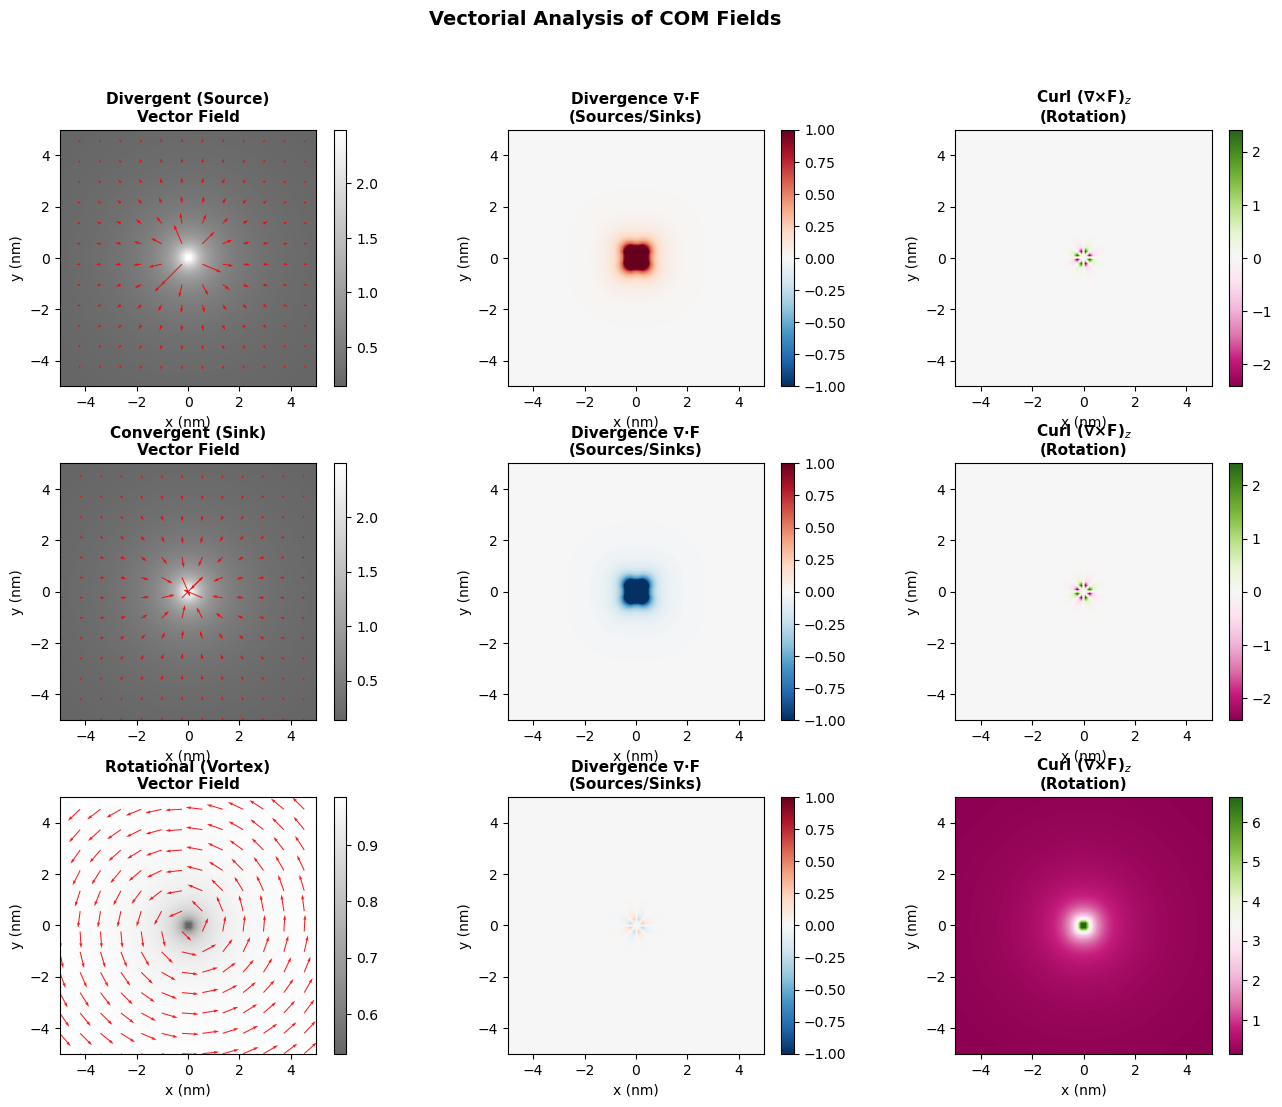


Physical Interpretation:
  • Divergence ≠ 0: Electric charges (Gauss's law)
  • Curl ≠ 0: Magnetic fields / currents (Ampère's law)
  • COM as vector field reveals underlying physical sources


In [6]:
# Analyze vectorial properties of COM

# Create different field configurations

# 1. Divergent field (point charge)
r_field = np.sqrt(X_test**2 + Y_test**2) + 0.1  # Avoid division by zero
field_div_x = X_test / r_field**2
field_div_y = Y_test / r_field**2

# 2. Convergent field (opposite charge)
field_conv_x = -X_test / r_field**2
field_conv_y = -Y_test / r_field**2

# 3. Rotational field (magnetic vortex)
field_rot_x = -Y_test / r_field
field_rot_y = X_test / r_field

# Calculate divergence and curl for each
def calculate_div_curl(field_x, field_y, dx, dy):
    """Calculate divergence and curl of a 2D vector field."""
    # Divergence: ∂Fx/∂x + ∂Fy/∂y
    dFx_dx = np.gradient(field_x, dx, axis=1)
    dFy_dy = np.gradient(field_y, dy, axis=0)
    divergence = dFx_dx + dFy_dy
    
    # Curl (z-component): ∂Fy/∂x - ∂Fx/∂y
    dFy_dx = np.gradient(field_y, dx, axis=1)
    dFx_dy = np.gradient(field_x, dy, axis=0)
    curl_z = dFy_dx - dFx_dy
    
    return divergence, curl_z

dx_test = x_test[1] - x_test[0]
dy_test = y_test[1] - y_test[0]

div_div, curl_div = calculate_div_curl(field_div_x, field_div_y, dx_test, dy_test)
div_conv, curl_conv = calculate_div_curl(field_conv_x, field_conv_y, dx_test, dy_test)
div_rot, curl_rot = calculate_div_curl(field_rot_x, field_rot_y, dx_test, dy_test)

print(f"\nVector Field Analysis:")
print(f"\n1. Divergent Field (Point Source):")
print(f"   Divergence: {np.mean(div_div[20:40, 20:40]):.3f} (positive - source)")
print(f"   Curl:       {np.mean(curl_div[20:40, 20:40]):.3f} (zero - irrotational)")

print(f"\n2. Convergent Field (Point Sink):")
print(f"   Divergence: {np.mean(div_conv[20:40, 20:40]):.3f} (negative - sink)")
print(f"   Curl:       {np.mean(curl_conv[20:40, 20:40]):.3f} (zero - irrotational)")

print(f"\n3. Rotational Field (Vortex):")
print(f"   Divergence: {np.mean(div_rot[20:40, 20:40]):.3f} (zero - no source/sink)")
print(f"   Curl:       {np.mean(np.abs(curl_rot[20:40, 20:40])):.3f} (non-zero - rotational)")

# Visualize
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

fields = [
    ("Divergent (Source)", field_div_x, field_div_y, div_div, curl_div),
    ("Convergent (Sink)", field_conv_x, field_conv_y, div_conv, curl_conv),
    ("Rotational (Vortex)", field_rot_x, field_rot_y, div_rot, curl_rot)
]

for row, (title, fx, fy, div, curl) in enumerate(fields):
    # Vector field
    ax = fig.add_subplot(gs[row, 0])
    magnitude = np.sqrt(fx**2 + fy**2)
    im = ax.imshow(magnitude, extent=[-5, 5, -5, 5], cmap='gray',
                  origin='lower', alpha=0.6, interpolation='bilinear')
    stride = 5
    ax.quiver(X_test[::stride, ::stride], Y_test[::stride, ::stride],
             fx[::stride, ::stride], fy[::stride, ::stride],
             color='red', scale=15, width=0.004, alpha=0.9)
    ax.set_xlabel('x (nm)', fontsize=10)
    ax.set_ylabel('y (nm)', fontsize=10)
    ax.set_title(f'{title}\nVector Field', fontsize=11, weight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # Divergence
    ax = fig.add_subplot(gs[row, 1])
    im = ax.imshow(div, extent=[-5, 5, -5, 5], cmap='RdBu_r',
                  origin='lower', interpolation='bilinear', vmin=-1, vmax=1)
    ax.set_xlabel('x (nm)', fontsize=10)
    ax.set_ylabel('y (nm)', fontsize=10)
    ax.set_title('Divergence ∇·F\n(Sources/Sinks)', fontsize=11, weight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # Curl
    ax = fig.add_subplot(gs[row, 2])
    im = ax.imshow(curl, extent=[-5, 5, -5, 5], cmap='PiYG',
                  origin='lower', interpolation='bilinear')
    ax.set_xlabel('x (nm)', fontsize=10)
    ax.set_ylabel('y (nm)', fontsize=10)
    ax.set_title('Curl (∇×F)$_z$\n(Rotation)', fontsize=11, weight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Vectorial Analysis of COM Fields', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\nPhysical Interpretation:")
print("  • Divergence ≠ 0: Electric charges (Gauss's law)")
print("  • Curl ≠ 0: Magnetic fields / currents (Ampère's law)")
print("  • COM as vector field reveals underlying physical sources")

## Summary

### Center-of-Mass (COM) Definition

**Mathematical**:
$$
\vec{\text{COM}}(\vec{r}) = \frac{\iint \vec{\theta} \cdot I(\vec{r}, \vec{\theta}) \, d^2\theta}{\iint I(\vec{r}, \vec{\theta}) \, d^2\theta}
$$

**Discrete** (for pixels):
$$
\text{COM}_x = \frac{\sum_{i,j} i \cdot I_{i,j}}{\sum_{i,j} I_{i,j}}, \quad \text{COM}_y = \frac{\sum_{i,j} j \cdot I_{i,j}}{\sum_{i,j} I_{i,j}}
$$



### Key Insights

**COM measures beam deflection**:
- Shift from reference position
- Proportional to phase gradient
- Direct visualization of electromagnetic fields

**Vector quantity**:
- Two components: COM_x, COM_y
- Forms vector field across sample
- Divergence/curl reveal sources

**Practical advantages**:
- Robust to noise (uses all detector pixels)
- Automatic normalization (division by total intensity)
- No reference wave needed
- Works with thick samples

### Workflow: 4D-STEM → COM → DPC

1. **Acquire 4D-STEM**: I(x, y, θ_x, θ_y)
2. **Calculate COM**: For each (x, y), compute COM of I(θ)
3. **Reference**: Subtract vacuum or average COM
4. **DPC signal**: COM shift = beam deflection
5. **Calibrate**: Convert pixels → angles → phase gradients
6. **Integrate**: iDPC to recover phase (optional)
7. **Interpret**: Map fields, potentials, defects

### Applications

**Electric fields**: p-n junctions, 2D materials, ferroelectrics

**Magnetic fields**: Domains, skyrmions, vortices

**Strain mapping**: Lattice distortions from COM shifts

**Defect imaging**: Dislocations, grain boundaries

**Beam-sensitive materials**: Low-dose phase imaging

### Further Reading

 **COM/DPC Methods**:
- Müller et al., "Atomic electric fields revealed by a quantum mechanical approach to electron picodiffraction," *Nat. Commun.* **5**, 5653 (2014)
- Close et al., "Towards quantitative, atomic-resolution reconstruction of the electrostatic potential via differential phase contrast," *Ultramicroscopy* **159**, 124 (2015)